**MACHINE LEARNING -Supervise,unsupervised,reinforcement**

supervised- training the model with output instance
1) regression- numerical data(continual value prediction) 
        a)linear regression
        b)multi
2)classification- catagorical data or a discrete value(binary form prediction)

unsupervised- learning by pattern

reinforcement- environment,agent,reward,penalties

step 1) import all libraries
step 2) import dataset using pandas ---- pd.read_csv()
step 3) EDA or preprocessing our dataset()
step 4) select target variable (x-input data , y-output data)
step 5) dividing the data into two parts ( traning or testing )- x,y both
        x train , x test
        y train , y test
step 6) import model (lr=linearregrassion)
step 7) tranning the data will be fitt on model (lr.fit(x_train, y_train))
step 8) make prediction (lr.predict(x_test))
step 9) check model evaluation matrices (r2 score ,mse , f1score, precision,recall , accuracy score)
step 10) convert model into pkl file and then we will make gui and make prediction using 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics



In [2]:
df = pd.read_excel('Linear_Regression_Practice_Dataset.xlsx')
print(df.head())
print(df.info())

  Student_ID  Study_Hours_Per_Day  Attendance_Percentage  \
0    STU_001                  4.5                   96.3   
1    STU_002                  9.1                   69.6   
2    STU_003                  7.4                   65.8   
3    STU_004                  6.3                   79.6   
4    STU_005                  2.7                   99.4   

   Sleep_Hours_Per_Night  Exam_Score  
0                    5.2        87.6  
1                    7.1       100.0  
2                    7.2        95.2  
3                    7.5        91.5  
4                    7.9        82.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             150 non-null    object 
 1   Study_Hours_Per_Day    150 non-null    float64
 2   Attendance_Percentage  150 non-null    float64
 3   Sleep_Hours_Per_Night  150 non-null 

In [3]:
df.isnull().sum()


Student_ID               0
Study_Hours_Per_Day      0
Attendance_Percentage    0
Sleep_Hours_Per_Night    0
Exam_Score               0
dtype: int64

In [4]:
print("---shape----")
df.shape

---shape----


(150, 5)

In [5]:
X = df[['Study_Hours_Per_Day', 'Attendance_Percentage', 'Sleep_Hours_Per_Night']]
y = df['Exam_Score']


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = lr.predict(X_test)

In [10]:
y_pred

array([ 97.12793921,  77.61805263,  99.58875081,  88.77521144,
       103.85632186,  72.94297605,  84.42597604,  75.89737993,
        72.65555714,  82.71754901,  80.17726157,  97.36232091,
        85.92485075,  95.63432821,  79.46235687,  65.74417903,
        96.25206638, 105.26136915,  96.66547557,  73.57731737,
        66.15156395, 103.37539353,  79.34964411,  71.99123961,
        77.24848564,  74.15672327,  80.79288961,  77.93073082,
        91.5462549 ,  88.17271947])

In [11]:
X_test

,Study_Hours_Per_Day,Attendance_Percentage,Sleep_Hours_Per_Night
73,8.0,74.7,7.7
18,5.0,61.6,5.6
118,8.6,74.4,7.7
78,4.4,95.7,8.3
76,7.7,98.9,8.4
31,2.9,64.5,8.0
64,3.7,88.5,8.8
141,3.5,61.5,8.9
68,2.1,86.0,5.8
82,4.1,83.1,7.5


In [12]:
y_test

73     100.0
18      77.6
118     99.7
78      93.3
76     100.0
31      69.0
64      85.5
141     79.2
68      76.3
82      81.8
110     87.3
12     100.0
36      87.4
9       95.2
19      77.0
56      60.4
104     96.3
69     100.0
55     100.0
132     66.6
29      61.4
127    100.0
26      82.2
128     82.0
131     72.8
145     74.4
108     78.2
143     74.5
45      90.9
30      86.2
Name: Exam_Score, dtype: float64

In [13]:
from sklearn.metrics import r2_score

In [14]:
r2 = r2_score(y_test ,y_pred)

In [15]:
r2

0.8956706107111105

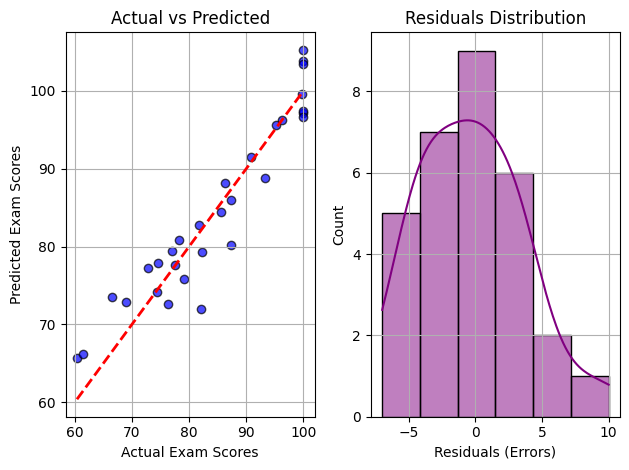

In [16]:
#Actual vs Predicted Scores
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal Line
plt.xlabel('Actual Exam Scores')
plt.ylabel('Predicted Exam Scores')
plt.title('Actual vs Predicted')
plt.grid(True)

#Residuals Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel('Residuals (Errors)')
plt.title('Residuals Distribution')
plt.grid(True)

plt.tight_layout()
plt.show()